In [1]:
#SCOPETYPE = 'OPENADC' #change as per your board specification
SCOPETYPE = 'OPENADC'
#PLATFORM = 'CWLITEARM'#change as per your board specification
PLATFORM = 'CW308_STM32F3'
SS_VER = 'SS_VER_1_1' #Do not change

In [2]:
%run "../../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 6056831                   to 16639448                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 4740612                   to 29538459                 
scope.clock.adc_rate                     changed from 4740612.0                 to 29538459.0        

We'll probably crash the target a few times while we're trying some glitching. Create a function to reset the target:

In [3]:
# Basically "refresh" for a board just like we do in our computer before proceeding to work.
#def reboot_flush():
 #   scope.io.nrst = False
  #  time.sleep(0.05)
   # scope.io.nrst = "high_z"
    #time.sleep(0.05)
    
    # Flush garbage too
    #target.flush()

In [4]:
import chipwhisperer as cw
from tqdm import trange
import numpy as np
import time

# 1. Connect to the Scope and Target
target = cw.target(scope)
scope.default_setup()
# Set the lengths for the PRESENT cipher!
target.output_len = 8
# 2. Flash your NEW firmware
firmware_path = "/home/pankaj/Documents/cw_crypto/chipwhisperer/firmware/mcu/simpleserial-present/simpleserial-present-CW308_STM32F3.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer, firmware_path)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5583 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5583 bytes


In [5]:
# 3. Reset the target by toggling the NRST pin
scope.io.nrst = 'low'
time.sleep(0.05)
scope.io.nrst = 'high_z'
time.sleep(0.05)
target.flush()

# 4. Set up the 10-byte PRESENT-80 Key
key = bytearray([0xAA, 0xBB, 0xCC, 0xDD, 0xEE, 0xFF, 0x11, 0x22, 0x33, 0x44])

# 5. Capture Loop
num_traces = 300
traces = []

print("Starting Capture...")
for i in trange(num_traces):
    # Generate a random 8-byte plaintext
    pt = bytearray(np.random.randint(0, 256, 8, dtype=np.uint8))
    
    # Send Key and Plaintext, and capture the power trace
    trace = cw.capture_trace(scope, target, pt, key)
    
    if trace is None:
        print(f"Capture failed at trace {i}")
        continue
        
    traces.append(trace)

print(f"Successfully captured {len(traces)} traces!")

# 6. Disconnect hardware when finished
scope.dis()
target.dis()


Starting Capture...


100%|█████████████████████████████████████████| 300/300 [00:06<00:00, 45.48it/s]

Successfully captured 300 traces!


In [6]:
import numpy as np

# 1. Convert captured traces to numpy arrays for fast vectorized math
trace_array = np.array([trace.wave for trace in traces])
textin_array = np.array([trace.textin for trace in traces])
num_traces, num_points = trace_array.shape

# 2. PRESENT S-Box and Hamming Weight Table
sbox = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]
HW = [bin(x).count('1') for x in range(16)]

recovered_key_nibbles = []
print("Starting Fast CPA Attack on PRESENT...\n")

# Loop through all 16 nibbles (64-bits) of the subkey
for nibble_idx in range(16):
    max_cpa = 0
    best_guess = 0
    
    # Test all 16 possible values for a 4-bit nibble
    for guess in range(16):
        # Build the hypothetical power model (Hamming Weight) for this guess
        hws = np.zeros(num_traces)
        for t in range(num_traces):
            pt_byte = textin_array[t][nibble_idx // 2]
            # Extract the correct High or Low 4-bit nibble from the plaintext byte
            pt_nibble = (pt_byte >> 4) if (nibble_idx % 2 == 0) else (pt_byte & 0x0F)
            
            # PRESENT Round 1: AddKey -> Sbox
            hws[t] = HW[sbox[pt_nibble ^ guess]]
            
        # Fast Numpy Vectorized Correlation across all trace points simultaneously
        hws_c = hws - hws.mean()
        traces_c = trace_array - trace_array.mean(axis=0)
        
        cov = np.dot(hws_c, traces_c)
        hw_std = np.sqrt(np.sum(hws_c**2))
        tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
        
        # Avoid division by zero
        tr_std[tr_std == 0] = 1 
        if hw_std == 0: hw_std = 1
            
        corr = np.abs(cov / (hw_std * tr_std))
        cpa_max = np.max(corr)
        
        # Record the guess with the highest correlation peak
        if cpa_max > max_cpa:
            max_cpa = cpa_max
            best_guess = guess
            
    recovered_key_nibbles.append(best_guess)
    print(f"Nibble {nibble_idx:2d} -> Recovered: {hex(best_guess)} (Confidence: {max_cpa:.4f})")

# Reconstruct the 64-bit recovered key
recovered_key = [(recovered_key_nibbles[i] << 4) | recovered_key_nibbles[i+1] for i in range(0, 16, 2)]

# Get the ACTUAL first 8 bytes of the key used during capture
actual_key = list(traces[0].key[:8])

print("\n--- ATTACK RESULTS ---")
print("Expected First 8 Bytes :", [hex(b) for b in actual_key])
print("Recovered First 8 Bytes:", [hex(b) for b in recovered_key])

if actual_key == recovered_key:
    print("\n✅ SUCCESS! The recovered key perfectly matches the real key!")
else:
    print("\n❌ FAILED! Some nibbles were incorrect. Try capturing more traces to eliminate ghost peaks.")


Starting Fast CPA Attack on PRESENT...

Nibble  0 -> Recovered: 0xa (Confidence: 0.7767)
Nibble  1 -> Recovered: 0xa (Confidence: 0.6407)
Nibble  2 -> Recovered: 0xb (Confidence: 0.6728)
Nibble  3 -> Recovered: 0xb (Confidence: 0.6489)
Nibble  4 -> Recovered: 0xc (Confidence: 0.6474)
Nibble  5 -> Recovered: 0xc (Confidence: 0.6656)
Nibble  6 -> Recovered: 0xd (Confidence: 0.6325)
Nibble  7 -> Recovered: 0xd (Confidence: 0.7011)
Nibble  8 -> Recovered: 0xe (Confidence: 0.6481)
Nibble  9 -> Recovered: 0xe (Confidence: 0.6557)
Nibble 10 -> Recovered: 0xf (Confidence: 0.6608)
Nibble 11 -> Recovered: 0xf (Confidence: 0.6842)
Nibble 12 -> Recovered: 0x1 (Confidence: 0.6384)
Nibble 13 -> Recovered: 0x1 (Confidence: 0.6037)
Nibble 14 -> Recovered: 0x2 (Confidence: 0.6536)
Nibble 15 -> Recovered: 0x2 (Confidence: 0.6698)

--- ATTACK RESULTS ---
Expected First 8 Bytes : ['0xaa', '0xbb', '0xcc', '0xdd', '0xee', '0xff', '0x11', '0x22']
Recovered First 8 Bytes: ['0xaa', '0xbb', '0xcc', '0xdd', '0xe

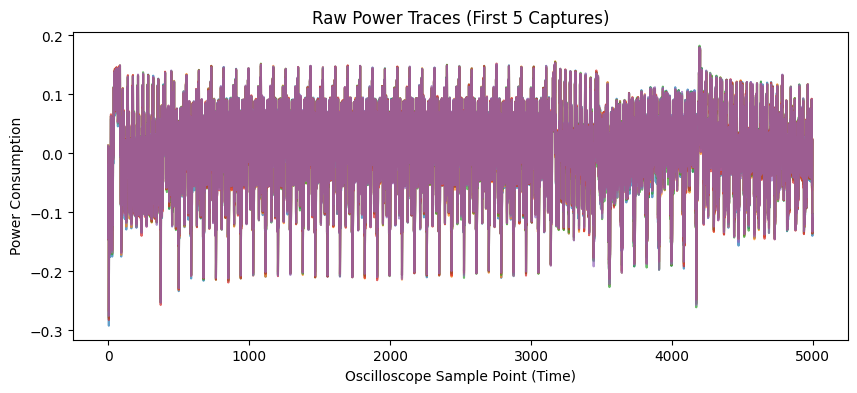

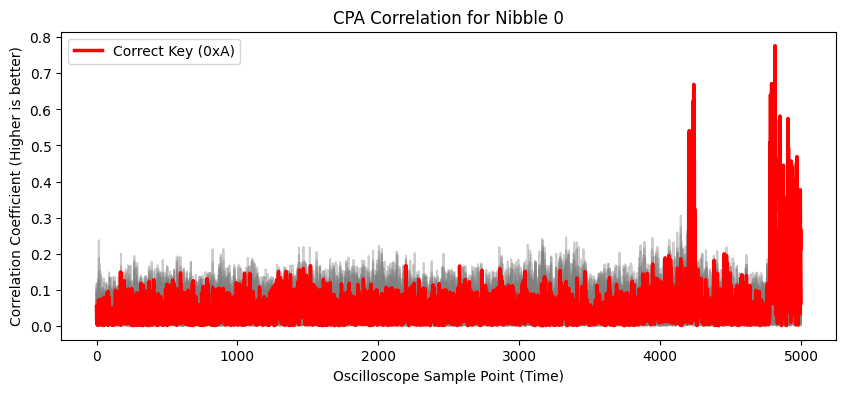

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# GRAPH 1: Visualize the Raw Power Traces
# ==========================================
plt.figure(figsize=(10, 4))
# We will just plot the first 5 traces so the graph isn't too cluttered
for i in range(5):
    plt.plot(trace_array[i], alpha=0.7)
    
plt.title("Raw Power Traces (First 5 Captures)")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Power Consumption")
plt.show()


# ==========================================
# GRAPH 2: Visualize the CPA Attack (Nibble 0)
# ==========================================
plt.figure(figsize=(10, 4))
nibble_idx = 0
correct_guess = 0xA  # Because our key starts with 0xAA

for guess in range(16):
    # Recalculate correlation for this specific guess
    hws = np.zeros(num_traces)
    for t in range(num_traces):
        pt_byte = textin_array[t][nibble_idx // 2]
        pt_nibble = pt_byte >> 4  # High nibble
        hws[t] = HW[sbox[pt_nibble ^ guess]]
        
    hws_c = hws - hws.mean()
    traces_c = trace_array - trace_array.mean(axis=0)
    
    cov = np.dot(hws_c, traces_c)
    hw_std = np.sqrt(np.sum(hws_c**2))
    tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
    tr_std[tr_std == 0] = 1
    if hw_std == 0: hw_std = 1
        
    corr = np.abs(cov / (hw_std * tr_std))
    
    # Draw the correct guess in RED, and wrong guesses in GRAY
    if guess == correct_guess:
        plt.plot(corr, color='red', linewidth=2.5, label=f"Correct Key (0x{guess:X})", zorder=10)
    else:
        plt.plot(corr, color='gray', alpha=0.4)

plt.title("CPA Correlation for Nibble 0")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Correlation Coefficient (Higher is better)")
plt.legend()
plt.show()


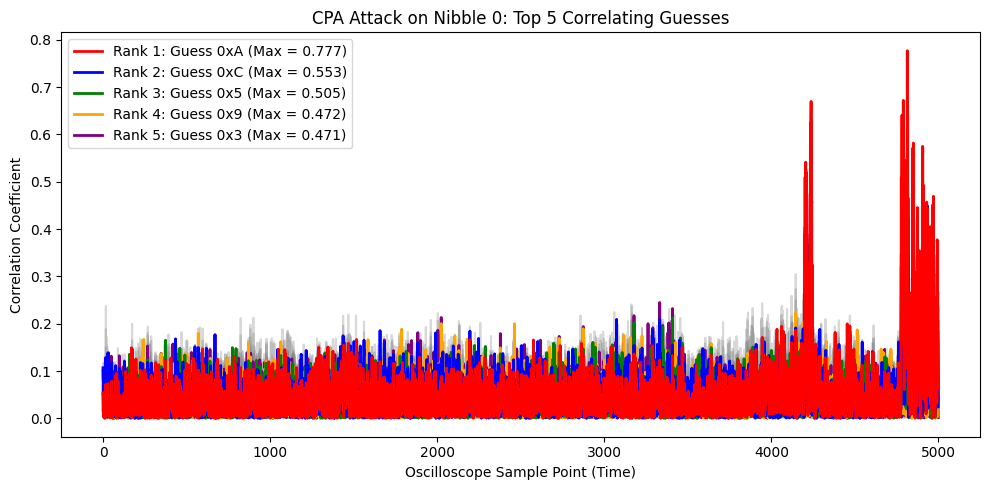

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
nibble_idx = 0

# A list to store the results for all 16 guesses
results = []

for guess in range(16):
    hws = np.zeros(num_traces)
    for t in range(num_traces):
        pt_byte = textin_array[t][nibble_idx // 2]
        pt_nibble = pt_byte >> 4  # High nibble
        hws[t] = HW[sbox[pt_nibble ^ guess]]
        
    hws_c = hws - hws.mean()
    traces_c = trace_array - trace_array.mean(axis=0)
    
    cov = np.dot(hws_c, traces_c)
    hw_std = np.sqrt(np.sum(hws_c**2))
    tr_std = np.sqrt(np.sum(traces_c**2, axis=0))
    tr_std[tr_std == 0] = 1
    if hw_std == 0: hw_std = 1
        
    corr = np.abs(cov / (hw_std * tr_std))
    
    max_corr = np.max(corr)
    results.append((guess, max_corr, corr))

# Sort the results by the maximum correlation, from highest to lowest
results.sort(key=lambda x: x[1], reverse=True)

# Colors for the top 5 guesses
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Plot them all
for rank, (guess, max_corr, corr) in enumerate(results):
    if rank < 5:
        # Plot the Top 5 with unique colors and add them to the legend
        plt.plot(corr, color=colors[rank], linewidth=2.0, 
                 label=f"Rank {rank+1}: Guess 0x{guess:X} (Max = {max_corr:.3f})", zorder=10-rank)
    else:
        # Plot the remaining bad guesses in light gray
        plt.plot(corr, color='gray', alpha=0.3, zorder=0)

plt.title(f"CPA Attack on Nibble {nibble_idx}: Top 5 Correlating Guesses")
plt.xlabel("Oscilloscope Sample Point (Time)")
plt.ylabel("Correlation Coefficient")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [9]:
##Differencial Power Attack

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sbox = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]
HW   = [bin(x).count('1') for x in range(16)]

print("Starting Improved DPA Attack on PRESENT (Round 1)...\n")
recovered_nibbles = []

for nibble_idx in range(16):
    max_dpa = 0
    best_guess = 0

    for guess in range(16):
        group_high = []  # traces where HW is HIGH (3 or 4)
        group_low  = []  # traces where HW is LOW (0 or 1)

        for t in range(num_traces):
            pt_byte = textin_array[t][nibble_idx // 2]
            pt_nibble = (pt_byte >> 4) if (nibble_idx % 2 == 0) else (pt_byte & 0x0F)

            intermediate = sbox[pt_nibble ^ guess]
            hw = HW[intermediate]

            # Only use traces with extreme HW values to maximize separation
            if hw >= 3:
                group_high.append(trace_array[t])
            elif hw <= 1:
                group_low.append(trace_array[t])

        if len(group_high) == 0 or len(group_low) == 0:
            continue

        diff = np.abs(np.mean(group_high, axis=0) - np.mean(group_low, axis=0))
        dpa_peak = np.max(diff)

        if dpa_peak > max_dpa:
            max_dpa = dpa_peak
            best_guess = guess

    recovered_nibbles.append(best_guess)
    print(f"Nibble {nibble_idx:2d} -> Recovered: {hex(best_guess)}  (DPA Peak: {max_dpa:.5f})")

# Reconstruct key
recovered_key_dpa = [(recovered_nibbles[i] << 4) | recovered_nibbles[i+1] for i in range(0, 16, 2)]
actual_key = list(traces[0].key[:8])

print("\n--- DPA ATTACK RESULTS ---")
print("Actual Key (First 8 Bytes) :", [hex(b) for b in actual_key])
print("Recovered Key (First 8 B)  :", [hex(b) for b in recovered_key_dpa])

if actual_key == recovered_key_dpa:
    print("\n✅ SUCCESS! Improved DPA recovered the key!")
else:
    print("\n❌ Still wrong. You need to capture 2000+ traces for DPA to work reliably.")
    print(f"   You currently have {num_traces} traces.")


Starting Improved DPA Attack on PRESENT (Round 1)...

Nibble  0 -> Recovered: 0xa  (DPA Peak: 0.00978)
Nibble  1 -> Recovered: 0xa  (DPA Peak: 0.00735)
Nibble  2 -> Recovered: 0xb  (DPA Peak: 0.00849)
Nibble  3 -> Recovered: 0xb  (DPA Peak: 0.01010)
Nibble  4 -> Recovered: 0xc  (DPA Peak: 0.00881)
Nibble  5 -> Recovered: 0xc  (DPA Peak: 0.00802)
Nibble  6 -> Recovered: 0xd  (DPA Peak: 0.00796)
Nibble  7 -> Recovered: 0xd  (DPA Peak: 0.00841)
Nibble  8 -> Recovered: 0xe  (DPA Peak: 0.00783)
Nibble  9 -> Recovered: 0xe  (DPA Peak: 0.00634)
Nibble 10 -> Recovered: 0xf  (DPA Peak: 0.00791)
Nibble 11 -> Recovered: 0xf  (DPA Peak: 0.00961)
Nibble 12 -> Recovered: 0x1  (DPA Peak: 0.00854)
Nibble 13 -> Recovered: 0x1  (DPA Peak: 0.00762)
Nibble 14 -> Recovered: 0x2  (DPA Peak: 0.00719)
Nibble 15 -> Recovered: 0x2  (DPA Peak: 0.00673)

--- DPA ATTACK RESULTS ---
Actual Key (First 8 Bytes) : ['0xaa', '0xbb', '0xcc', '0xdd', '0xee', '0xff', '0x11', '0x22']
Recovered Key (First 8 B)  : ['0xaa', '0

In [11]:
import numpy as np

# Slice to only 100 traces from your existing captures
traces_100 = traces[:300]

trace_array  = np.array([trace.wave   for trace in traces_100])
textin_array = np.array([trace.textin for trace in traces_100])
num_traces, _ = trace_array.shape

sbox = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]
HW   = [bin(x).count('1') for x in range(16)]
actual_key = list(traces_100[0].key[:8])

# Get actual nibbles from real key
actual_nibbles = []
for b in actual_key:
    actual_nibbles.append((b >> 4) & 0xF)
    actual_nibbles.append(b & 0xF)

print(f"Running CPA and DPA on {num_traces} traces...\n")
print(f"{'Nibble':<8} {'Actual':^8} {'CPA':^12} {'DPA':^12}")
print("-" * 45)

cpa_nibbles, dpa_nibbles = [], []

for nibble_idx in range(16):
    actual_nib = actual_nibbles[nibble_idx]

    # ---- CPA ----
    max_cpa, best_cpa = 0, 0
    for guess in range(16):
        hws = np.array([
            HW[sbox[((textin_array[t][nibble_idx//2] >> 4)
                      if nibble_idx % 2 == 0
                      else (textin_array[t][nibble_idx//2] & 0xF)) ^ guess]]
            for t in range(num_traces)
        ], dtype=float)
        hws_c    = hws - hws.mean()
        traces_c = trace_array - trace_array.mean(axis=0)
        cov      = np.dot(hws_c, traces_c)
        hw_std   = np.sqrt(np.sum(hws_c**2)) or 1
        tr_std   = np.sqrt(np.sum(traces_c**2, axis=0))
        tr_std[tr_std == 0] = 1
        corr = np.max(np.abs(cov / (hw_std * tr_std)))
        if corr > max_cpa:
            max_cpa, best_cpa = corr, guess
    cpa_nibbles.append(best_cpa)

    # ---- DPA ----
    max_dpa, best_dpa = 0, 0
    for guess in range(16):
        group_high, group_low = [], []
        for t in range(num_traces):
            pt_byte   = textin_array[t][nibble_idx // 2]
            pt_nibble = (pt_byte >> 4) if nibble_idx % 2 == 0 else (pt_byte & 0xF)
            hw = HW[sbox[pt_nibble ^ guess]]
            if hw >= 3:
                group_high.append(trace_array[t])
            elif hw <= 1:
                group_low.append(trace_array[t])
        if not group_high or not group_low:
            continue
        peak = np.max(np.abs(np.mean(group_high, axis=0) - np.mean(group_low, axis=0)))
        if peak > max_dpa:
            max_dpa, best_dpa = peak, guess
    dpa_nibbles.append(best_dpa)

    cpa_ok = "✅" if best_cpa == actual_nib else f"❌(got 0x{best_cpa:X})"
    dpa_ok = "✅" if best_dpa == actual_nib else f"❌(got 0x{best_dpa:X})"

    print(f"{nibble_idx:<8} 0x{actual_nib:X}      {cpa_ok:<14} {dpa_ok}")

# Final score
cpa_key = [(cpa_nibbles[i] << 4) | cpa_nibbles[i+1] for i in range(0, 16, 2)]
dpa_key = [(dpa_nibbles[i] << 4) | dpa_nibbles[i+1] for i in range(0, 16, 2)]
cpa_score = sum(1 for a,b in zip(cpa_key, actual_key) if a==b)
dpa_score = sum(1 for a,b in zip(dpa_key, actual_key) if a==b)

print(f"\n--- FINAL SCORE (100 traces) ---")
print(f"CPA recovered {cpa_score}/8 bytes correctly")
print(f"DPA recovered {dpa_score}/8 bytes correctly")


Running CPA and DPA on 300 traces...

Nibble    Actual      CPA          DPA     
---------------------------------------------
0        0xA      ✅              ✅
1        0xA      ✅              ✅
2        0xB      ✅              ✅
3        0xB      ✅              ✅
4        0xC      ✅              ✅
5        0xC      ✅              ✅
6        0xD      ✅              ✅
7        0xD      ✅              ✅
8        0xE      ✅              ✅
9        0xE      ✅              ✅
10       0xF      ✅              ✅
11       0xF      ✅              ✅
12       0x1      ✅              ✅
13       0x1      ✅              ✅
14       0x2      ✅              ✅
15       0x2      ✅              ✅

--- FINAL SCORE (100 traces) ---
CPA recovered 8/8 bytes correctly
DPA recovered 8/8 bytes correctly


In [12]:
# Try different sizes to see how accuracy changes!
for subset_size in [50, 100, 150, 200,250,300]:
    traces_subset = traces[:subset_size]
    trace_array   = np.array([trace.wave   for trace in traces_subset])
    textin_array  = np.array([trace.textin for trace in traces_subset])
    num_traces, _ = trace_array.shape

    # --- CPA ---
    cpa_nibbles = []
    sbox = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]
    HW   = [bin(x).count('1') for x in range(16)]

    for nibble_idx in range(16):
        max_cpa, best_cpa = 0, 0
        for guess in range(16):
            hws = np.array([
                HW[sbox[((textin_array[t][nibble_idx//2] >> 4)
                          if nibble_idx % 2 == 0
                          else (textin_array[t][nibble_idx//2] & 0xF)) ^ guess]]
                for t in range(num_traces)
            ], dtype=float)
            hws_c    = hws - hws.mean()
            traces_c = trace_array - trace_array.mean(axis=0)
            cov      = np.dot(hws_c, traces_c)
            hw_std   = np.sqrt(np.sum(hws_c**2)) or 1
            tr_std   = np.sqrt(np.sum(traces_c**2, axis=0))
            tr_std[tr_std == 0] = 1
            corr = np.max(np.abs(cov / (hw_std * tr_std)))
            if corr > max_cpa:
                max_cpa, best_cpa = corr, guess
        cpa_nibbles.append(best_cpa)

    # --- DPA ---
    dpa_nibbles = []
    for nibble_idx in range(16):
        max_dpa, best_dpa = 0, 0
        for guess in range(16):
            group_high, group_low = [], []
            for t in range(num_traces):
                pt_byte   = textin_array[t][nibble_idx // 2]
                pt_nibble = (pt_byte >> 4) if nibble_idx % 2 == 0 else (pt_byte & 0xF)
                hw = HW[sbox[pt_nibble ^ guess]]
                if hw >= 3:
                    group_high.append(trace_array[t])
                elif hw <= 1:
                    group_low.append(trace_array[t])
            if not group_high or not group_low:
                continue
            peak = np.max(np.abs(np.mean(group_high, axis=0) - np.mean(group_low, axis=0)))
            if peak > max_dpa:
                max_dpa, best_dpa = peak, guess
        dpa_nibbles.append(best_dpa)

    # Score each method
    actual_key   = list(traces_subset[0].key[:8])
    cpa_key = [(cpa_nibbles[i] << 4) | cpa_nibbles[i+1] for i in range(0, 16, 2)]
    dpa_key = [(dpa_nibbles[i] << 4) | dpa_nibbles[i+1] for i in range(0, 16, 2)]

    cpa_score = sum(1 for a, b in zip(cpa_key, actual_key) if a == b)
    dpa_score = sum(1 for a, b in zip(dpa_key, actual_key) if a == b)

    print(f"Traces: {subset_size:4d} | "
          f"CPA: {cpa_score}/8 bytes {'✅' if cpa_score==8 else '❌'} | "
          f"DPA: {dpa_score}/8 bytes {'✅' if dpa_score==8 else '❌'}")


Traces:   50 | CPA: 4/8 bytes ❌ | DPA: 2/8 bytes ❌
Traces:  100 | CPA: 7/8 bytes ❌ | DPA: 4/8 bytes ❌
Traces:  150 | CPA: 8/8 bytes ✅ | DPA: 6/8 bytes ❌
Traces:  200 | CPA: 8/8 bytes ✅ | DPA: 8/8 bytes ✅
Traces:  250 | CPA: 8/8 bytes ✅ | DPA: 6/8 bytes ❌
Traces:  300 | CPA: 8/8 bytes ✅ | DPA: 8/8 bytes ✅
